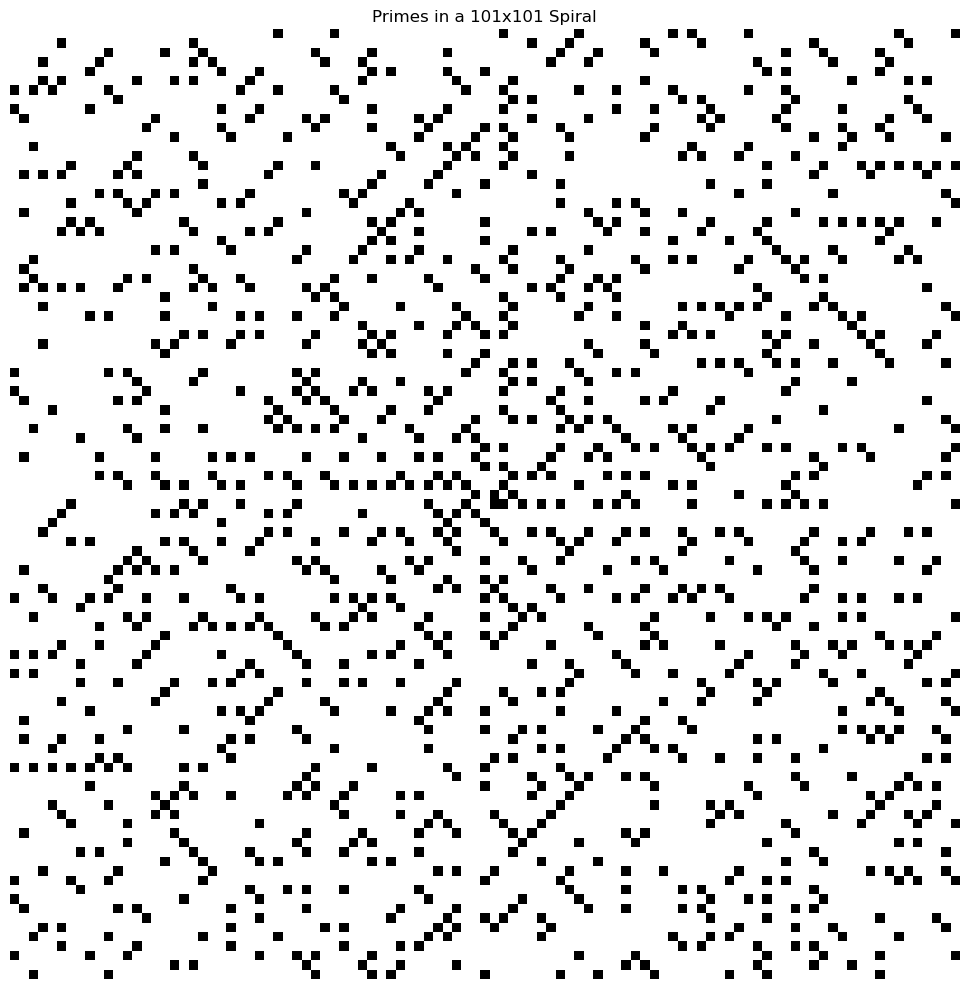


Primes on each diagonal of the 101x101 spiral:

NE diagonal:
[np.int64(3), np.int64(13), np.int64(31), np.int64(241), np.int64(307), np.int64(463), np.int64(757), np.int64(1123), np.int64(1723), np.int64(3307), np.int64(3541), np.int64(4831), np.int64(5113), np.int64(5701), np.int64(6007), np.int64(8011), np.int64(9901)]

NW diagonal:
[np.int64(5), np.int64(17), np.int64(37), np.int64(101), np.int64(197), np.int64(257), np.int64(401), np.int64(577), np.int64(677), np.int64(1297), np.int64(1601), np.int64(2917), np.int64(3137), np.int64(4357), np.int64(5477), np.int64(7057), np.int64(8101), np.int64(8837)]

SW diagonal:
[np.int64(7), np.int64(43), np.int64(73), np.int64(157), np.int64(211), np.int64(421), np.int64(601), np.int64(1483), np.int64(2551), np.int64(2971), np.int64(3907), np.int64(4423), np.int64(6163), np.int64(6481), np.int64(8191)]

SE diagonal:
[]

Counts:
NE: 17
NW: 18
SW: 15
SE: 0


In [4]:
import numpy as np
import matplotlib.pyplot as plt

def build_spiral(n: int) -> np.ndarray:
    if n % 2 == 0:
        raise ValueError("n must be odd so the spiral has a centre.")

    grid = np.zeros((n, n), dtype=int)

    # start in centre
    x = y = n // 2
    grid[y, x] = 1

    num = 2
    step_length = 1

    # directions: right, up, left, down
    directions = [(1, 0), (0, -1), (-1, 0), (0, 1)]

    while num <= n * n:
        for d in range(4):
            dx, dy = directions[d]

            # increase step length after every 2 directions
            steps = step_length
            for _ in range(steps):
                if num > n * n:
                    break
                x += dx
                y += dy
                if 0 <= x < n and 0 <= y < n:
                    grid[y, x] = num
                num += 1

            if d % 2 == 1:
                step_length += 1

    return grid


def sieve(limit: int) -> np.ndarray:
    is_prime = np.ones(limit + 1, dtype=bool)
    is_prime[:2] = False

    for p in range(2, int(limit**0.5) + 1):
        if is_prime[p]:
            is_prime[p * p : limit + 1 : p] = False

    return is_prime



n = 101   
grid = build_spiral(n)
is_prime = sieve(n * n)


prime_mask = is_prime[grid]

plt.figure(figsize=(10, 10))
plt.imshow(prime_mask, cmap="binary", interpolation="nearest")
plt.title(f"Primes in a {n}x{n} Spiral")
plt.axis("off")
plt.tight_layout()


plt.savefig("prime_spiral_101x101.png", dpi=300, bbox_inches="tight")
plt.savefig("prime_spiral.png", dpi=300, bbox_inches='tight')
plt.show()

centre = n // 2

# Diagonals leaving the centre
diag_NE = [grid[centre - k, centre + k] for k in range(1, centre + 1)]  # up-right
diag_NW = [grid[centre - k, centre - k] for k in range(1, centre + 1)]  # up-left
diag_SW = [grid[centre + k, centre - k] for k in range(1, centre + 1)]  # down-left
diag_SE = [grid[centre + k, centre + k] for k in range(1, centre + 1)]  # down-right

# Keep only primes
prime_NE = [x for x in diag_NE if is_prime[x]]
prime_NW = [x for x in diag_NW if is_prime[x]]
prime_SW = [x for x in diag_SW if is_prime[x]]
prime_SE = [x for x in diag_SE if is_prime[x]]

print("\nPrimes on each diagonal of the 101x101 spiral:\n")

print("NE diagonal:")
print(prime_NE)
print()

print("NW diagonal:")
print(prime_NW)
print()

print("SW diagonal:")
print(prime_SW)
print()

print("SE diagonal:")
print(prime_SE)
print()

print("Counts:")
print(f"NE: {len(prime_NE)}")
print(f"NW: {len(prime_NW)}")
print(f"SW: {len(prime_SW)}")
print(f"SE: {len(prime_SE)}")

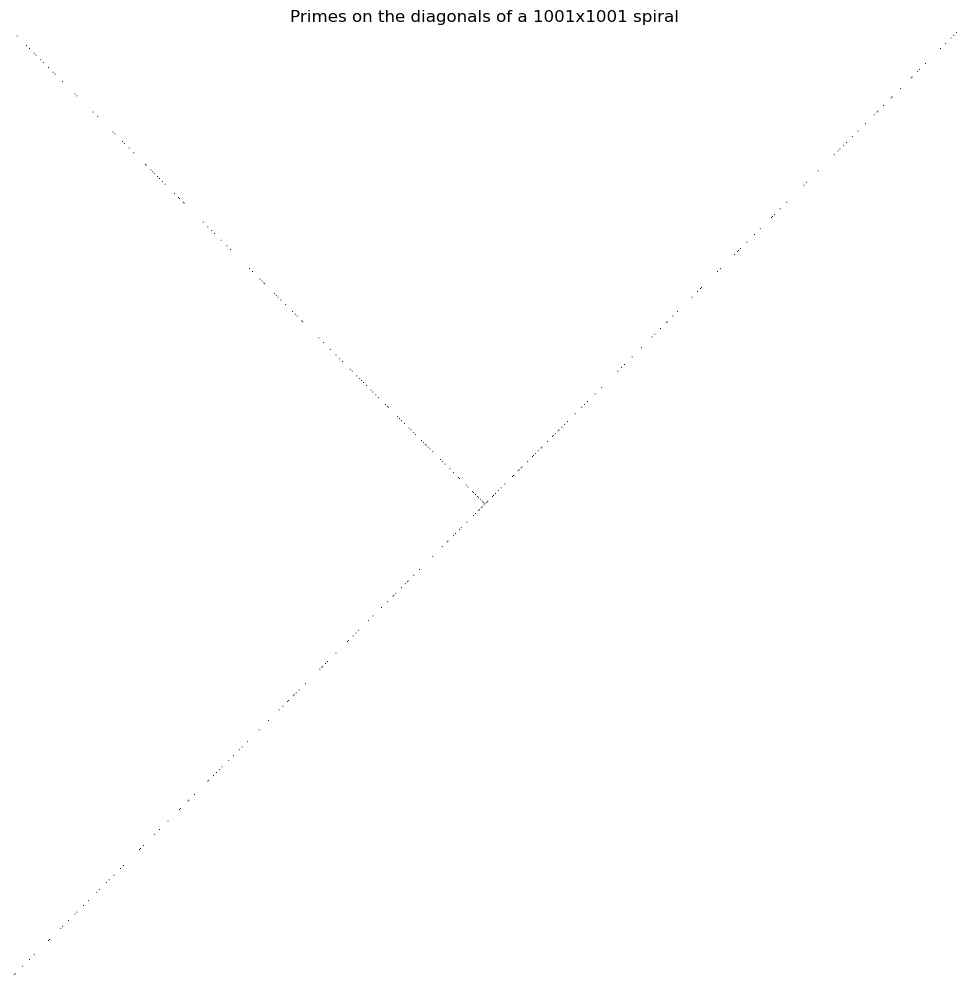

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Build a 1001x1001 Ulam-style spiral, then highlight only
# the primes that lie on the two main diagonals of the grid.
# ------------------------------------------------------------

N = 1001
assert N % 2 == 1, "Grid size must be odd."

# -------- Sieve of Eratosthenes --------
def sieve(limit: int) -> np.ndarray:
    is_prime = np.ones(limit + 1, dtype=bool)
    is_prime[:2] = False
    for p in range(2, int(limit**0.5) + 1):
        if is_prime[p]:
            is_prime[p*p : limit + 1 : p] = False
    return is_prime

# -------- Build spiral grid --------
def make_spiral(n: int) -> np.ndarray:
    grid = np.zeros((n, n), dtype=np.int32)

    x = y = n // 2
    grid[y, x] = 1
    current = 2
    step = 1

    # Directions: right, up, left, down
    directions = [(1, 0), (0, -1), (-1, 0), (0, 1)]

    while current <= n * n:
        for d in range(4):
            dx, dy = directions[d]
            for _ in range(step):
                if current > n * n:
                    break
                x += dx
                y += dy
                grid[y, x] = current
                current += 1
            # Increase step length after every 2 directions
            if d % 2 == 1:
                step += 1

    return grid

# -------- Main --------
grid = make_spiral(N)
is_prime = sieve(N * N)

# Mask for the two main diagonals
diag_mask = np.zeros((N, N), dtype=bool)
idx = np.arange(N)
diag_mask[idx, idx] = True
diag_mask[idx, N - 1 - idx] = True

# Keep only prime entries on the diagonals
prime_diag_mask = is_prime[grid] & diag_mask

# Plot
plt.figure(figsize=(10, 10))
plt.imshow(prime_diag_mask, cmap="gray_r", origin="upper")
plt.title(f"Primes on the diagonals of a {N}x{N} spiral")
plt.axis("off")
plt.tight_layout()
plt.savefig("prime_diagonals_1001.png", dpi=300, bbox_inches="tight")
plt.show()